# Understanding DOE Plots (Design of Experiments Plots)

**DOE Plots** are a family of graphical tools used in **designed experiments** to visualise how different factors affect a response variable. There are four key DOE plots:

| Plot | What it shows |
|---|---|
| **DEX Scatter Plot** | Raw data across all factor combinations — overview |
| **DEX Mean Plot** | Mean response at each level of each factor — which factors matter |
| **DEX SD Plot** | Standard deviation at each factor level — which factors affect variability |
| **DEX Contour Plot** | Response surface over two factors — 2D interaction map |

**DOE context:** A designed experiment systematically varies factors at specified levels (e.g., Temperature ∈ {Low, High}, Pressure ∈ {Low, High}) to study their effects on a response variable (e.g., yield). DOE plots help identify which factors are significant and how they interact.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from IPython.display import SVG, display
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)

# ── Synthetic 2^3 factorial design ──
# Factors: Temperature (−1/+1), Pressure (−1/+1), Time (−1/+1)
# Response: yield (%)
n_rep = 3

factors = pd.DataFrame([
    {'Temp': -1, 'Pressure': -1, 'Time': -1},
    {'Temp': +1, 'Pressure': -1, 'Time': -1},
    {'Temp': -1, 'Pressure': +1, 'Time': -1},
    {'Temp': +1, 'Pressure': +1, 'Time': -1},
    {'Temp': -1, 'Pressure': -1, 'Time': +1},
    {'Temp': +1, 'Pressure': -1, 'Time': +1},
    {'Temp': -1, 'Pressure': +1, 'Time': +1},
    {'Temp': +1, 'Pressure': +1, 'Time': +1},
])

# Yield model: mainly affected by Temperature and Temp×Pressure interaction
def yield_model(T, P, Ti):
    return 75 + 8*T + 3*P + 2*Ti + 4*T*P + np.random.normal(0, 2)

rows = []
for _ in range(n_rep):
    for _, row in factors.iterrows():
        rows.append({
            'Temp': row['Temp'],
            'Pressure': row['Pressure'],
            'Time': row['Time'],
            'Yield': yield_model(row['Temp'], row['Pressure'], row['Time'])
        })

df = pd.DataFrame(rows)
df['Temp_label']     = df['Temp'].map({-1: 'Low', 1: 'High'})
df['Pressure_label'] = df['Pressure'].map({-1: 'Low', 1: 'High'})
df['Time_label']     = df['Time'].map({-1: 'Short', 1: 'Long'})

print("Experiment data summary:")
print(df.groupby(['Temp_label', 'Pressure_label', 'Time_label'])['Yield'].agg(['mean', 'std']).round(2))
print(f"\nOverall mean yield: {df['Yield'].mean():.1f}%")

Experiment data summary:
                                       mean   std
Temp_label Pressure_label Time_label             
High       High           Long        91.19  2.21
                          Short       87.76  3.00
           Low            Long        76.42  1.94
                          Short       74.48  0.69
Low        High           Long        67.95  3.31
                          Short       63.52  1.60
           Low            Long        70.98  1.75
                          Short       65.34  1.53

Overall mean yield: 74.7%


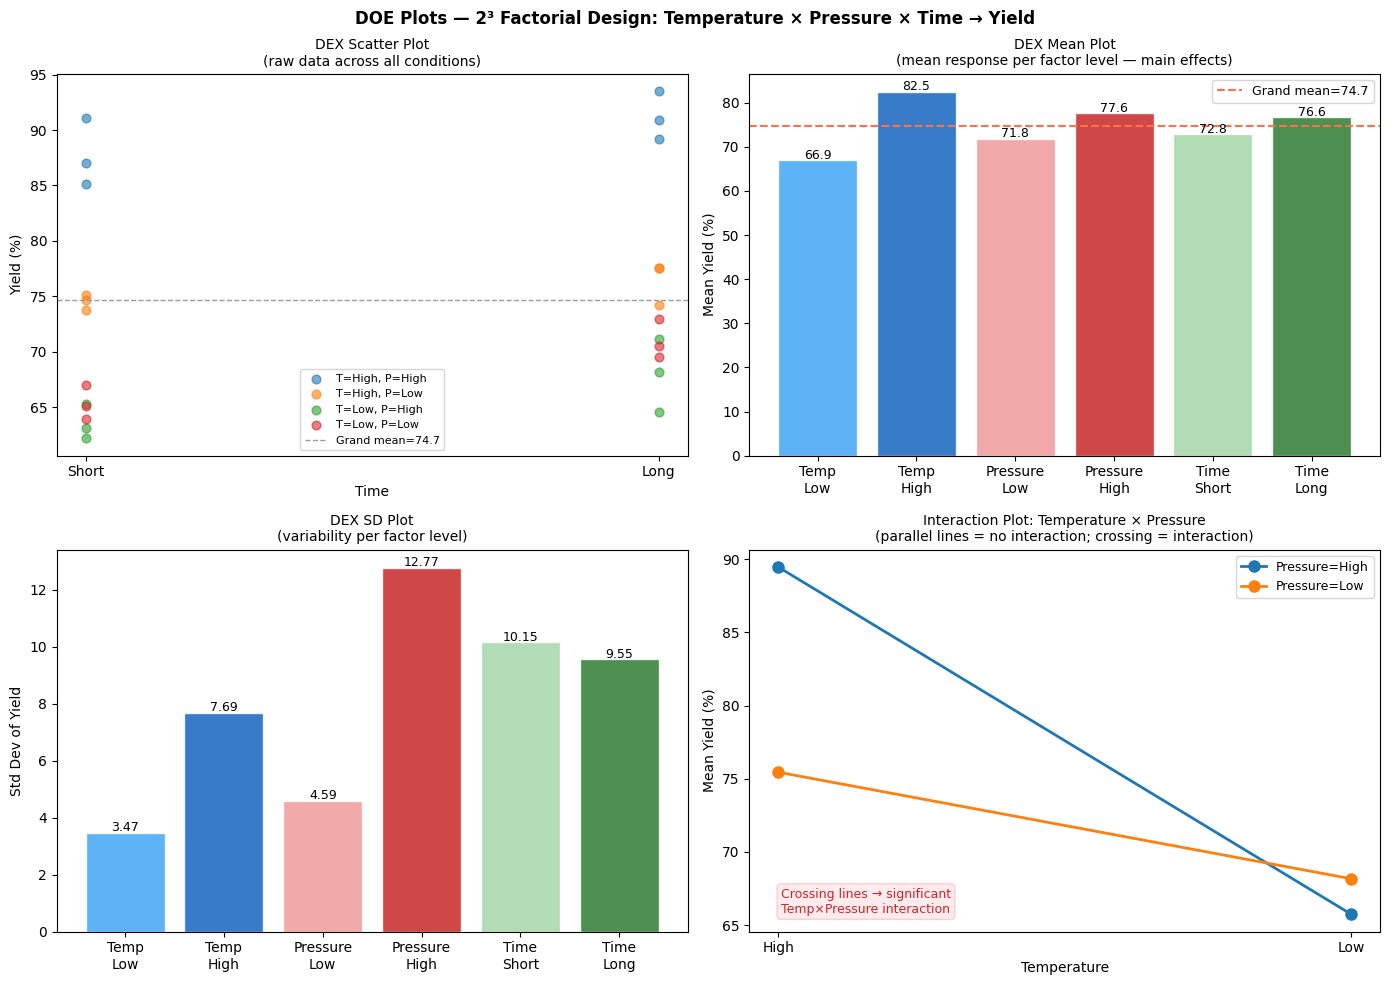

In [2]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('DOE Plots — 2³ Factorial Design: Temperature × Pressure × Time → Yield',
             fontsize=12, fontweight='bold')

overall_mean = df['Yield'].mean()

# ── Panel 1: DEX Scatter Plot ──
ax = axes[0, 0]
for combo, grp in df.groupby(['Temp_label', 'Pressure_label']):
    label = f'T={combo[0]}, P={combo[1]}'
    ax.scatter(grp['Time_label'], grp['Yield'], alpha=0.6, s=40, label=label)
ax.set_title('DEX Scatter Plot\n(raw data across all conditions)', fontsize=10)
ax.set_xlabel('Time')
ax.set_ylabel('Yield (%)')
ax.axhline(overall_mean, color='#9E9E9E', linewidth=1, linestyle='--', label=f'Grand mean={overall_mean:.1f}')
ax.legend(fontsize=8)

# ── Panel 2: DEX Mean Plot (main effects) ──
ax = axes[0, 1]
factor_means = {
    'Temp\nLow': df[df['Temp']==-1]['Yield'].mean(),
    'Temp\nHigh': df[df['Temp']==+1]['Yield'].mean(),
    'Pressure\nLow': df[df['Pressure']==-1]['Yield'].mean(),
    'Pressure\nHigh': df[df['Pressure']==+1]['Yield'].mean(),
    'Time\nShort': df[df['Time']==-1]['Yield'].mean(),
    'Time\nLong': df[df['Time']==+1]['Yield'].mean(),
}
colors = ['#42A5F5','#1565C0', '#EF9A9A','#C62828', '#A5D6A7','#2E7D32']
bars = ax.bar(factor_means.keys(), factor_means.values(), color=colors, edgecolor='white', alpha=0.85)
ax.axhline(overall_mean, color='#FF7043', linewidth=1.5, linestyle='--', label=f'Grand mean={overall_mean:.1f}')
ax.set_title('DEX Mean Plot\n(mean response per factor level — main effects)', fontsize=10)
ax.set_ylabel('Mean Yield (%)')
ax.legend(fontsize=9)
for bar, val in zip(bars, factor_means.values()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{val:.1f}', ha='center', fontsize=9)

# ── Panel 3: DEX SD Plot ──
ax = axes[1, 0]
factor_sds = {
    'Temp\nLow': df[df['Temp']==-1]['Yield'].std(),
    'Temp\nHigh': df[df['Temp']==+1]['Yield'].std(),
    'Pressure\nLow': df[df['Pressure']==-1]['Yield'].std(),
    'Pressure\nHigh': df[df['Pressure']==+1]['Yield'].std(),
    'Time\nShort': df[df['Time']==-1]['Yield'].std(),
    'Time\nLong': df[df['Time']==+1]['Yield'].std(),
}
bars = ax.bar(factor_sds.keys(), factor_sds.values(), color=colors, edgecolor='white', alpha=0.85)
ax.set_title('DEX SD Plot\n(variability per factor level)', fontsize=10)
ax.set_ylabel('Std Dev of Yield')
for bar, val in zip(bars, factor_sds.values()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
            f'{val:.2f}', ha='center', fontsize=9)

# ── Panel 4: Interaction Plot (Temp × Pressure) ──
ax = axes[1, 1]
for p_level, grp in df.groupby('Pressure_label'):
    means = grp.groupby('Temp_label')['Yield'].mean()
    ax.plot(means.index, means.values, 'o-', linewidth=2, markersize=8,
            label=f'Pressure={p_level}')
ax.set_title('Interaction Plot: Temperature × Pressure\n(parallel lines = no interaction; crossing = interaction)', fontsize=10)
ax.set_xlabel('Temperature')
ax.set_ylabel('Mean Yield (%)')
ax.legend(fontsize=9)
ax.text(0.05, 0.05, 'Crossing lines → significant\nTemp×Pressure interaction',
        transform=ax.transAxes, fontsize=9, color='#C62828',
        bbox=dict(facecolor='#FFEBEE', edgecolor='#FFCDD2', boxstyle='round'))

plt.tight_layout()
plt.show()

## Key Takeaways

| | |
|---|---|
| **DOE context** | Controlled experiment: factors are deliberately varied at specified levels |
| **DEX Scatter Plot** | Shows raw data across all combinations — reveals outliers and spread |
| **DEX Mean Plot** | Tallest deviation from grand mean → most important factor (main effect) |
| **DEX SD Plot** | Factor level with large SD → affects variability (variance factor) |
| **Interaction Plot** | Parallel lines → no interaction; crossing lines → interaction present |
| **Interaction** | Effect of factor A depends on level of factor B — must be included in the model |
| **2^k design** | k factors at 2 levels each → 2^k combinations |
| **vs ANOVA** | DOE plots are graphical; ANOVA provides formal p-values — use both |
| **Optimisation** | Identify factor levels that maximise (or minimise) the response variable |